Depth | Train Accuracy | Test Accuracy
1 | 0.96 | 0.99
2 | 0.963 | 0.99
3 | 0.965 | 0.99
5 | 0.97 | 0.96
10 | 0.998 | 0.94


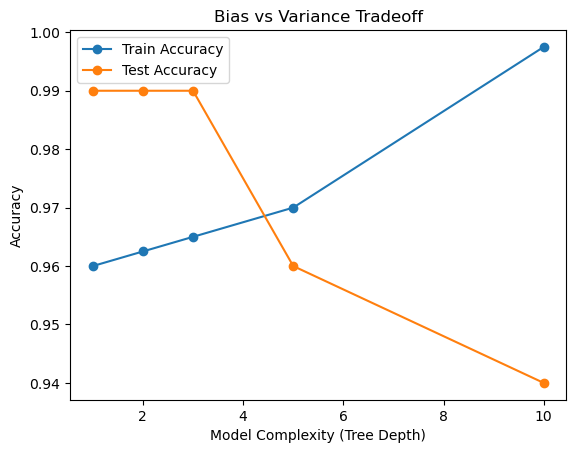


Best Depth: 1

Generalization Observation:
Low depth = Underfitting
Very high depth = Overfitting
Balanced train and test accuracy = Good Generalization


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = pd.read_csv("creditcard_small.csv")

# Features and Target
X = data.drop("Class", axis=1)
y = data["Class"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Different model complexities
depths = [1, 2, 3, 5, 10]

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

# Show results
print("Depth | Train Accuracy | Test Accuracy")

for i in range(len(depths)):
    print(
        depths[i],
        "|",
        round(train_scores[i], 3),
        "|",
        round(test_scores[i], 3)
    )

# Learning Curve
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')

plt.xlabel("Model Complexity (Tree Depth)")
plt.ylabel("Accuracy")
plt.title("Bias vs Variance Tradeoff")
plt.legend()
plt.show()

# Conclusion
best_depth = depths[test_scores.index(max(test_scores))]

print("\nBest Depth:", best_depth)

print("\nGeneralization Observation:")
print("Low depth = Underfitting")
print("Very high depth = Overfitting")
print("Balanced train and test accuracy = Good Generalization")